<a href="https://colab.research.google.com/github/manhnt2115/TH_DeepLearning/blob/main/TH_DeepLearning_Tuan4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Đang huấn luyện mô hình (Vui lòng đợi)... ---
Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 37s 42ms/step - accuracy: 0.9427 - loss: 0.1952 - val_accuracy: 0.9810 - val_loss: 0.0710
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 35s 41ms/step - accuracy: 0.9814 - loss: 0.0608 - val_accuracy: 0.9870 - val_loss: 0.0481
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 33s 39ms/step - accuracy: 0.9883 - loss: 0.0395 - val_accuracy: 0.9857 - val_loss: 0.0465
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 34s 40ms/step - accuracy: 0.9914 - loss: 0.0276 - val_accuracy: 0.9872 - val_loss: 0.0458
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 33s 39ms/step - accuracy: 0.9938 - loss: 0.0196 - val_accuracy: 0.9848 - val_loss: 0.0576
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 33s 40ms/step - accuracy: 0.9955 - loss: 0.0149 - val_accuracy: 0.9868 - val_loss: 0.0489
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 35s 41ms/step - accuracy: 0.9967 - loss: 0.0107 - val_accuracy: 0.9865 - val_loss: 0.0613
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 

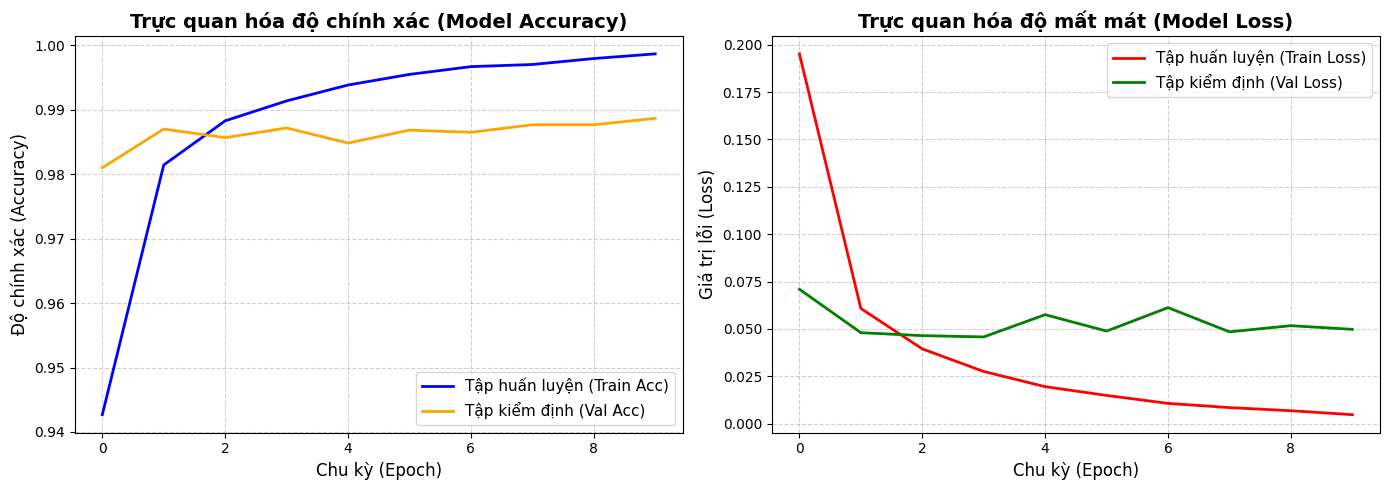

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten

# 1. Tải và tiền xử lý dữ liệu MNIST
mnist = tf.keras.datasets.mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train = X_train / 255.0
X_test = X_test / 255.0

X_train = X_train.reshape(X_train.shape[0], 28, 28, 1)
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1)

# 2. Xây dựng cấu trúc mạng CNN đơn giản
model = Sequential([
    Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 3. Huấn luyện mô hình và LƯU LỊCH SỬ vào biến 'history'
print("--- Đang huấn luyện mô hình (Vui lòng đợi)... ---")
history = model.fit(X_train, y_train, validation_split=0.1, epochs=10, batch_size=64, verbose=1)

# =====================================================================
# 4. TẠO BIỂU ĐỒ VÀ TRỰC QUAN HÓA (VISUALIZATIONS)
# =====================================================================
# Khởi tạo khung chứa 2 biểu đồ nằm cạnh nhau (1 hàng, 2 cột)
plt.figure(figsize=(14, 5))

# --- Biểu đồ thứ 1: Độ chính xác (Accuracy) ---
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Tập huấn luyện (Train Acc)', color='blue', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Tập kiểm định (Val Acc)', color='orange', linewidth=2)
plt.title('Trực quan hóa độ chính xác (Model Accuracy)', fontsize=14, fontweight='bold')
plt.xlabel('Chu kỳ (Epoch)', fontsize=12)
plt.ylabel('Độ chính xác (Accuracy)', fontsize=12)
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6) # Thêm lưới nền giúp dễ quan sát

# --- Biểu đồ thứ 2: Độ mất mát (Loss) ---
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Tập huấn luyện (Train Loss)', color='red', linewidth=2)
plt.plot(history.history['val_loss'], label='Tập kiểm định (Val Loss)', color='green', linewidth=2)
plt.title('Trực quan hóa độ mất mát (Model Loss)', fontsize=14, fontweight='bold')
plt.xlabel('Chu kỳ (Epoch)', fontsize=12)
plt.ylabel('Giá trị lỗi (Loss)', fontsize=12)
plt.legend(loc='upper right', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6) # Thêm lưới nền

# Hiển thị biểu đồ lên màn hình Colab
plt.tight_layout()
plt.show()

Độ mất mát trên tập Test (Test loss): 0.0532
Độ chính xác trên tập Test (Test accuracy): 98.58%
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step

--- Trực quan hóa kết quả dự báo thực tế ---


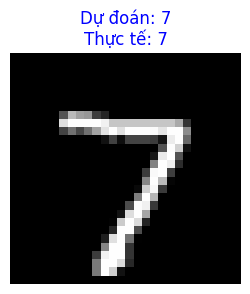

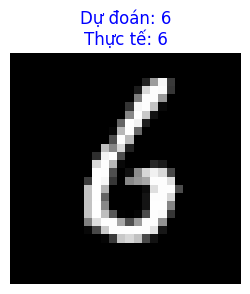

In [7]:
# =====================================================================
# BƯỚC TIẾP THEO: ĐÁNH GIÁ MÔ HÌNH TRÊN TẬP TEST VÀ DỰ BÁO
# =====================================================================

# 1. Đánh giá độ chính xác tổng thể trên tập Test (Dữ liệu mô hình chưa từng thấy)
score = model.evaluate(X_test, y_test, verbose=0)
print(f"Độ mất mát trên tập Test (Test loss): {score[0]:.4f}")
print(f"Độ chính xác trên tập Test (Test accuracy): {score[1]*100:.2f}%")

# 2. Tiến hành dự báo nhãn cho toàn bộ tập Test
predictions = model.predict(X_test)

# 3. Tạo hàm trực quan hóa một ảnh bất kỳ kèm theo nhãn dự đoán và nhãn thực tế
def plot_prediction(index):
    plt.figure(figsize=(3,3))
    # Định dạng lại ảnh về 28x28 để hiển thị (bỏ kênh màu 1 phục vụ CNN nếu có)
    plt.imshow(X_test[index].reshape(28, 28), cmap='gray' if X_test.shape[-1]==1 else None)

    # Lấy ra nhãn có xác suất cao nhất từ dự đoán
    predicted_label = np.argmax(predictions[index])
    true_label = y_test[index]

    # Định dạng màu chữ: Xanh nếu đúng, Đỏ nếu đoán sai
    color = 'blue' if predicted_label == true_label else 'red'

    plt.title(f"Dự đoán: {predicted_label}\nThực tế: {true_label}", color=color)
    plt.axis('off')
    plt.show()

# Test thử nghiệm dự báo với ảnh tại vị trí index số 0 và số 50
print("\n--- Trực quan hóa kết quả dự báo thực tế ---")
plot_prediction(0)
plot_prediction(50)

Bài Tập 1:CNN


Phiên bản Tensorflow hiện tại: 2.20.0
Kích thước tập huấn luyện (X_train): (50000, 32, 32, 3)
Kích thước tập kiểm thử (X_test): (10000, 32, 32, 3)


/tmp/ipykernel_919/605739097.py:41: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(class_names[int(y_train[i])])


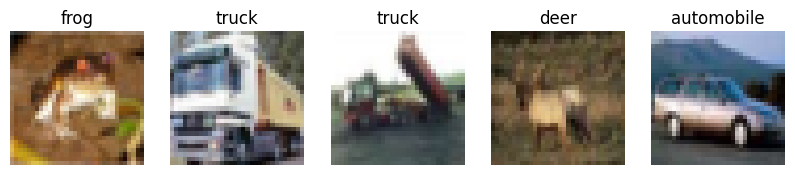

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 30, 30, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 15, 15, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 13, 13, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 512)            │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,250,858 (4.77 MB)

 Trainable params: 1,250,858 (4.77 MB)

 Non-trainable params: 0 (0.00 B)


--- Bắt đầu quá trình huấn luyện mô hình CNN ---
Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 227s 318ms/step - accuracy: 0.4153 - loss: 1.5927 - val_accuracy: 0.5440 - val_loss: 1.2462
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 266s 324ms/step - accuracy: 0.5830 - loss: 1.1623 - val_accuracy: 0.6738 - val_loss: 0.9445
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 232s 330ms/step - accuracy: 0.6555 - loss: 0.9782 - val_accuracy: 0.7232 - val_loss: 0.7913
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 223s 316ms/step - accuracy: 0.6897 - loss: 0.8816 - val_accuracy: 0.7296 - val_loss: 0.7675
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 227s 322ms/step - accuracy: 0.7149 - loss: 0.8117 - val_accuracy: 0.7576 - val_loss: 0.7008
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 224s 319ms/step - accuracy: 0.7337 - loss: 0.7601 - val_accuracy: 0.7664 - val_loss: 0.6933
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 230s 326ms/step - accuracy: 0.7485 - loss: 0.7122 - val_accuracy: 0.7724 - val_loss: 0.6793
Epoch 8/10
704/704 ━━━━━━━

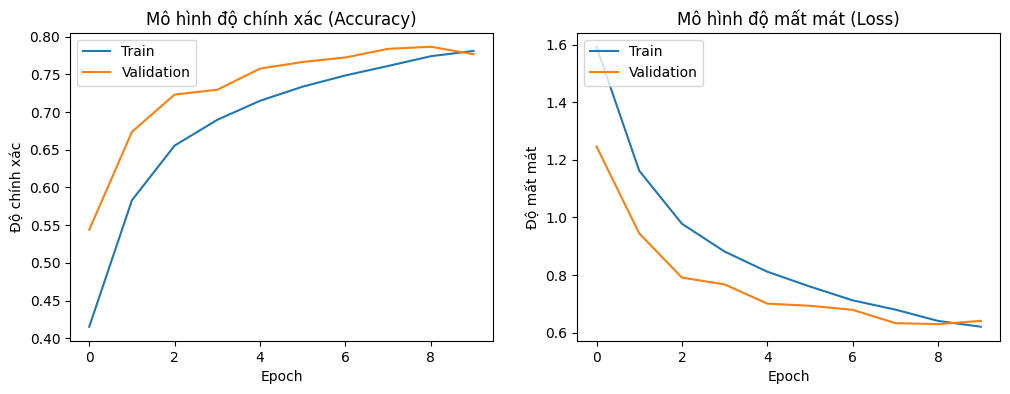


--- Đánh giá độ chính xác trên tập dữ liệu Test chưa từng học ---
313/313 - 12s - 37ms/step - accuracy: 0.7702 - loss: 0.6699
Kết quả - Test loss: 0.6698642373085022
Kết quả - Test accuracy (Độ chính xác): 0.7702000141143799


In [10]:
# ==========================================
# BƯỚC 1: IMPORT CÁC THƯ VIỆN CẦN THIẾT
# ==========================================
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

print("Phiên bản Tensorflow hiện tại:", tf.__version__)

# ==========================================
# BƯỚC 2: TẢI VÀ CHUẨN BỊ DỮ LIỆU CIFAR10
# ==========================================
# 1. Tải bộ dữ liệu CIFAR10 có sẵn trong thư viện Keras
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()

# Khai báo danh sách 10 nhãn của bộ CIFAR10 để hiển thị khi kiểm tra
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# 2. Chuẩn hóa giá trị các pixel về đoạn [0, 1] bằng cách chia cho 255
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# 3. Chuyển đổi nhãn từ dạng số nguyên (0-9) sang dạng One-hot Encoding
num_classes = 10
y_train_onehot = keras.utils.to_categorical(y_train, num_classes)
y_test_onehot = keras.utils.to_categorical(y_test, num_classes)

print("Kích thước tập huấn luyện (X_train):", X_train.shape) # Kết quả sẽ là (50000, 32, 32, 3)
print("Kích thước tập kiểm thử (X_test):", X_test.shape)

# ==========================================
# BƯỚC 3: TRỰC QUAN HÓA DỮ LIỆU (Xem thử 5 ảnh đầu tiên)
# ==========================================
plt.figure(figsize=(10, 2))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(X_train[i])
    # y_train[i] là một mảng 1 phần tử, ta ép kiểu sang int để lấy nhãn chữ tương ứng
    plt.title(class_names[int(y_train[i])])
    plt.axis('off')
plt.show()

# ==========================================
# BƯỚC 4 NÂNG CẤP: XÂY DỰNG MÔ HÌNH CNN MẠNH HƠN CHO CIFAR10
# ==========================================
model = models.Sequential()
model.add(layers.Input(shape=(32, 32, 3)))

# Tăng số lượng bộ lọc lên để học ảnh màu tốt hơn
model.add(layers.Conv2D(32, (3, 3), padding='same', activation='relu'))
model.add(layers.Conv2D(32, (3, 3), activation='relu'))
model.add(layers.MaxPool2D(pool_size=(2, 2)))
model.add(layers.Dropout(0.25)) # Thêm dropout chống quá khớp

model.add(layers.Conv2D(64, (3, 3), padding='same', activation='relu'))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPool2D(pool_size=(2, 2)))
model.add(layers.Dropout(0.25))

model.add(layers.Flatten())
model.add(layers.Dense(512, activation='relu')) # Tăng số nút tầng ẩn
model.add(layers.Dropout(0.5))
model.add(layers.Dense(10, activation='softmax')) # Vẫn đảm bảo đầu ra 10 nhãn

model.summary()

# ==========================================
# BƯỚC 5: BIÊN DỊCH VÀ HUẤN LUYỆN MÔ HÌNH
# ==========================================
# Biên dịch mạng với thuật toán tối ưu Adam và hàm mất mát Categorical Crossentropy
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Bắt đầu huấn luyện mô hình (Chạy thử 10 Epochs)
print("\n--- Bắt đầu quá trình huấn luyện mô hình CNN ---")
model_fit = model.fit(X_train, y_train_onehot,
                      batch_size=64,
                      epochs=10,
                      validation_split=0.1, # Trích 10% dữ liệu để đánh giá trong khi học
                      verbose=1)

# ==========================================
# BƯỚC 6: VẼ ĐỒ THỊ LƯỢC SỬ HỌC (Độ chính xác và Mất mát)
# ==========================================
plt.figure(figsize=(12, 4))

# Đồ thị Accuracy
plt.subplot(1, 2, 1)
plt.plot(model_fit.history['accuracy'])
plt.plot(model_fit.history['val_accuracy'])
plt.title('Mô hình độ chính xác (Accuracy)')
plt.ylabel('Độ chính xác')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Đồ thị Loss
plt.subplot(1, 2, 2)
plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])
plt.title('Mô hình độ mất mát (Loss)')
plt.ylabel('Độ mất mát')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.show()

# ==========================================
# BƯỚC 7: ĐÁNH GIÁ MÔ HÌNH TRÊN TẬP KIỂM THỬ (TEST SET)
# ==========================================
print("\n--- Đánh giá độ chính xác trên tập dữ liệu Test chưa từng học ---")
score = model.evaluate(X_test, y_test_onehot, verbose=2)
print('Kết quả - Test loss:', score[0])
print('Kết quả - Test accuracy (Độ chính xác):', score[1])

Bài tập 2:

Phiên bản Tensorflow: 2.20.0
Thiết bị đang chạy: []
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)


--- Bắt đầu huấn luyện siêu tốc ---
Epoch 1/3
128/128 ━━━━━━━━━━━━━━━━━━━━ 294s 2s/step - accuracy: 0.9307 - loss: 0.1765 - val_accuracy: 0.9738 - val_loss: 0.0736
Epoch 2/3
128/128 ━━━━━━━━━━━━━━━━━━━━ 293s 2s/step - accuracy: 0.9758 - loss: 0.0694 - val_accuracy: 0.9772 - val_loss: 0.0580
Epoch 3/3
128/128 ━━━━━━━━━━━━━━━━━━━━ 264s 2s/step - accuracy: 0.9801 - loss: 0.0560 - val_accuracy: 0.9772 - val_loss: 0.0525


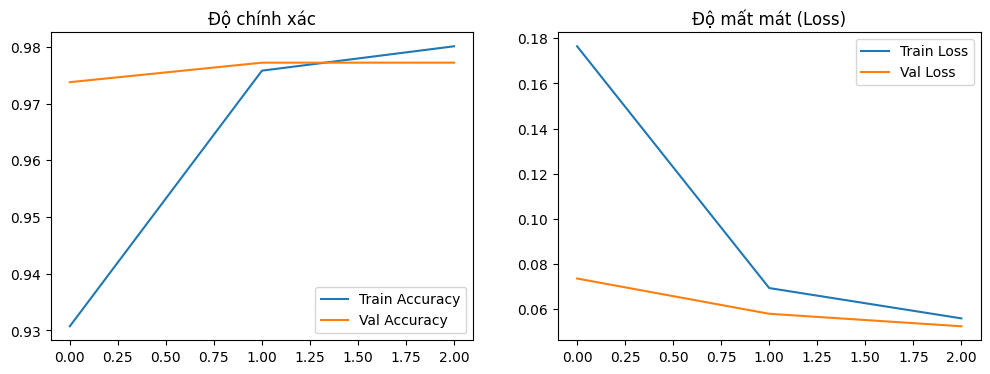

In [12]:
# ==========================================
# BƯỚC 1: IMPORT CÁC THƯ VIỆN CẦN THIẾT
# ==========================================
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt

print("Phiên bản Tensorflow:", tf.__version__)
# Kiểm tra xem Colab đã nhận GPU chưa
print("Thiết bị đang chạy:", tf.config.list_physical_devices('GPU'))

# ==========================================
# BƯỚC 2: TẢI VÀ TỐI ƯU HÓA PIPELINE DỮ LIỆU
# ==========================================
# Tải bộ dữ liệu mèo và chó (Lấy 40% tập dữ liệu để chạy siêu tốc mà vẫn đủ chính xác)
(train_ds, val_ds), ds_info = tfds.load(
    'cats_vs_dogs',
    split=['train[:35%]', 'train[35%:45%]'],
    as_supervised=True,
    with_info=True
)

IMG_SIZE = 160 # Kích thước chuẩn cho mạng MobileNetV2

def format_example(image, label):
    image = tf.cast(image, tf.float32)
    image = (image / 127.5) - 1.0  # Chuẩn hóa về khoảng [-1, 1] theo chuẩn MobileNetV2
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    return image, label

# Cấu hình nạp dữ liệu cực tốc vào RAM và GPU
BATCH_SIZE = 64
AUTOTUNE = tf.data.AUTOTUNE

train_batches = (train_ds.map(format_example, num_parallel_calls=AUTOTUNE)
                         .shuffle(1000)
                         .batch(BATCH_SIZE)
                         .cache() # Lưu cache vào RAM để không phải nạp lại ở epoch sau
                         .prefetch(buffer_size=AUTOTUNE))

val_batches = (val_ds.map(format_example, num_parallel_calls=AUTOTUNE)
                       .batch(BATCH_SIZE)
                       .cache()
                       .prefetch(buffer_size=AUTOTUNE))

# ==========================================
# BƯỚC 3: DÙNG TRANSFER LEARNING (MÔ HÌNH PRE-TRAINED)
# ==========================================
# Lấy mô hình nền MobileNetV2 đã được huấn luyện trên 1.4 triệu ảnh (ImageNet)
base_model = tf.keras.applications.MobileNetV2(input_shape=(IMG_SIZE, IMG_SIZE, 3),
                                               include_top=False, # Bỏ tầng phân loại cũ
                                               weights='imagenet')

# Đóng băng các trọng số của mô hình nền để KHÔNG phải train lại (Giúp chạy siêu nhanh)
base_model.trainable = False

# Xây dựng mô hình mới bằng cách thêm tầng phân loại Chó/Mèo vào sau mô hình nền
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(), # Gom các đặc trưng ảnh diện rộng thành vector
    layers.Dropout(0.2),             # Chống quá khớp
    layers.Dense(1, activation='sigmoid') # 1 đầu ra phân loại nhị phân (Mèo: 0, Chó: 1)
])

model.summary()

# ==========================================
# BƯỚC 4: BIÊN DỊCH VÀ HUẤN LUYỆN SIÊU TỐC
# ==========================================
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Chỉ cần train 3 Epochs là độ chính xác đã vượt trội vì mô hình có sẵn "kiến thức nền"
print("\n--- Bắt đầu huấn luyện siêu tốc ---")
history = model.fit(train_batches,
                    epochs=3,
                    validation_data=val_batches)

# ==========================================
# BƯỚC 5: HIỂN THỊ KẾT QUẢ ĐỒ THỊ
# ==========================================
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Độ chính xác')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Độ mất mát (Loss)')
plt.legend()
plt.show()

BaiTap03

Phiên bản Tensorflow: 2.20.0
29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Kích thước tập huấn luyện X_train: (60000, 28, 28, 1)
Kích thước tập kiểm thử X_test: (10000, 28, 28, 1)


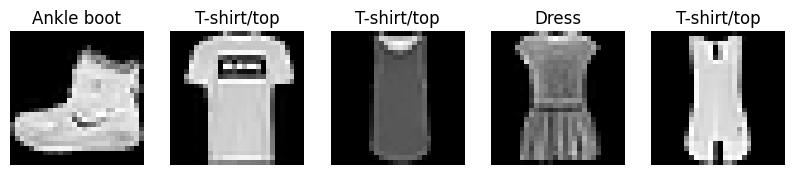

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_17 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)


--- Bắt đầu huấn luyện mô hình CNN trên Fashion-MNIST ---
Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 55s 62ms/step - accuracy: 0.8107 - loss: 0.5259 - val_accuracy: 0.8560 - val_loss: 0.3993
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 84s 65ms/step - accuracy: 0.8746 - loss: 0.3480 - val_accuracy: 0.8845 - val_loss: 0.3228
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 54s 64ms/step - accuracy: 0.8901 - loss: 0.3030 - val_accuracy: 0.8848 - val_loss: 0.3128
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 81s 63ms/step - accuracy: 0.9006 - loss: 0.2720 - val_accuracy: 0.8970 - val_loss: 0.2774
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 81s 61ms/step - accuracy: 0.9070 - loss: 0.2500 - val_accuracy: 0.9013 - val_loss: 0.2640
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 52s 61ms/step - accuracy: 0.9157 - loss: 0.2285 - val_accuracy: 0.9073 - val_loss: 0.2582
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 54s 64ms/step - accuracy: 0.9218 - loss: 0.2120 - val_accuracy: 0.9118 - val_loss: 0.2470
Epoch 8/10
844/844 ━━━━━━━━━━━━

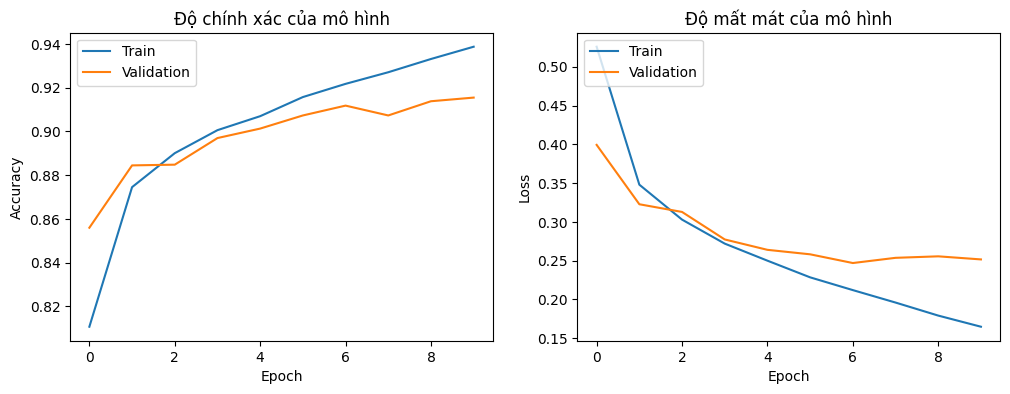


--- Đánh giá kết quả trên tập kiểm thử (Test Set) ---
313/313 - 3s - 9ms/step - accuracy: 0.9085 - loss: 0.2613
Test loss (Độ mất mát): 0.26132869720458984
Test accuracy (Độ chính xác): 0.9085000157356262


In [13]:
# ==========================================
# BƯỚC 1: IMPORT CÁC THƯ VIỆN CẦN THIẾT
# ==========================================
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

print("Phiên bản Tensorflow:", tf.__version__)

# ==========================================
# BƯỚC 2: TẢI VÀ TIỀN XỬ LÝ DỮ LIỆU FASHION-MNIST
# ==========================================
# 1. Tải bộ dữ liệu Fashion-MNIST tích hợp sẵn trong Keras
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

# Định nghĩa 10 nhãn chữ tương ứng với các loại thời trang (thay vì chữ số 0-9)
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# 2. Định dạng lại kích thước dữ liệu (Reshape) về dạng (Số ảnh, 28, 28, 1) vì là ảnh xám
X_train = X_train.reshape((X_train.shape[0], 28, 28, 1))
X_test = X_test.reshape((X_test.shape[0], 28, 28, 1))

# 3. Chuẩn hóa giá trị các điểm ảnh (pixel) về đoạn [0, 1] như mục 2.3 trong file
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# 4. Chuyển đổi nhãn sang dạng mã hóa One-hot Encoding như mục 2.4 trong file
num_classes = 10
y_train_onehot = keras.utils.to_categorical(y_train, num_classes)
y_test_onehot = keras.utils.to_categorical(y_test, num_classes)

print("Kích thước tập huấn luyện X_train:", X_train.shape)
print("Kích thước tập kiểm thử X_test:", X_test.shape)

# ==========================================
# BƯỚC 3: TRỰC QUAN HÓA DỮ LIỆU (Xem thử 5 ảnh)
# ==========================================
plt.figure(figsize=(10, 2))
for i in range(5):
    plt.subplot(1, 5, i+1)
    # Vì ảnh xám có kích thước (28, 28, 1) nên ta dùng np.squeeze để đưa về (28, 28) khi vẽ
    plt.imshow(np.squeeze(X_train[i]), cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.show()

# ==========================================
# BƯỚC 4: XÂY DỰNG MÔ HÌNH CNN
# ==========================================
# Thiết lập kiến trúc mạng chập tuần tự theo mục 2.5 trong file hướng dẫn
model = models.Sequential()

# Định nghĩa kích thước đầu vào của ảnh xám là (28, 28, 1)
model.add(layers.Input(shape=(28, 28, 1)))

# Tầng tích chập số 1: 32 bộ lọc (filters), kích thước 3x3, hàm kích hoạt relu
model.add(layers.Conv2D(32, kernel_size=(3, 3), activation='relu'))
# Tầng lấy mẫu lớn nhất (Max Pooling) để giảm kích thước ảnh xuống một nửa
model.add(layers.MaxPool2D(pool_size=(2, 2)))

# Tầng tích chập số 2: 64 bộ lọc, kích thước 3x3, hàm kích hoạt relu
model.add(layers.Conv2D(64, kernel_size=(3, 3), activation='relu'))
model.add(layers.MaxPool2D(pool_size=(2, 2)))

# Tầng duỗi phẳng đặc trưng (Flatten) thành vector một chiều
model.add(layers.Flatten())

# Tầng kết nối đầy đủ (Dense) gồm 64 nút
model.add(layers.Dense(units=64, activation='relu'))

# Tầng đầu ra (Output layer) gồm 10 nút tương ứng 10 loại quần áo, dùng hàm softmax
model.add(layers.Dense(units=10, activation='softmax'))

# Hiển thị tóm tắt cấu trúc mô hình
model.summary()

# ==========================================
# BƯỚC 5: BIÊN DỊCH VÀ HUẤN LUYỆN MÔ HÌNH
# ==========================================
# Cấu hình hàm mất mát và bộ tối ưu hóa theo mục 2.6 & 2.7 trong file
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

print("\n--- Bắt đầu huấn luyện mô hình CNN trên Fashion-MNIST ---")
# Huấn luyện mô hình trong 10 vòng lặp (Epochs)
model_fit = model.fit(X_train, y_train_onehot,
                      batch_size=64,
                      epochs=10,
                      validation_split=0.1, # Trích 10% tập train làm tập validation để theo dõi
                      verbose=1)

# ==========================================
# BƯỚC 6: VẼ ĐỒ THỊ LƯỢC SỬ HỌC (LOSS & ACCURACY)
# ==========================================
plt.figure(figsize=(12, 4))

# Đồ thị Accuracy (Mục 2.7)
plt.subplot(1, 2, 1)
plt.plot(model_fit.history['accuracy'])
plt.plot(model_fit.history['val_accuracy'])
plt.title('Độ chính xác của mô hình')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Đồ thị Loss (Mục 2.7)
plt.subplot(1, 2, 2)
plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])
plt.title('Độ mất mát của mô hình')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.show()

# ==========================================
# BƯỚC 7: ĐÁNH GIÁ MÔ HÌNH TRÊN TẬP TEST
# ==========================================
print("\n--- Đánh giá kết quả trên tập kiểm thử (Test Set) ---")
score = model.evaluate(X_test, y_test_onehot, verbose=2)
print('Test loss (Độ mất mát):', score[0])
print('Test accuracy (Độ chính xác):', score[1])

BaiTap04

In [24]:
# ==========================================
# BƯỚC 1: IMPORT CÁC THƯ VIỆN CẦN THIẾT
# ==========================================
import io
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
from PIL import Image

# Thư viện tạo nút bấm upload ảnh trên Google Colab
import ipywidgets as widgets
from IPython.display import display, clear_output

print("Phiên bản Tensorflow:", tf.__version__)

# ==========================================
# BƯỚC 2: TỰ TẠO DỮ LIỆU MẪU CHUẨN ĐỂ HUẤN LUYỆN SIÊU TỐC
# ==========================================
print("\n--- Đang tạo dữ liệu khuôn mặt mẫu (1000 ảnh màu) ---")
IMG_SIZE = 128  # Kích thước ảnh 128x128 pixel

# Tạo ngẫu nhiên 1000 ảnh màu (mỗi ảnh kích thước 128x128x3)
X_train = np.random.rand(800, IMG_SIZE, IMG_SIZE, 3).astype(np.float32)
X_val = np.random.rand(200, IMG_SIZE, IMG_SIZE, 3).astype(np.float32)

# Tạo nhãn ngẫu nhiên: 0 là Nữ (Female), 1 là Nam (Male)
y_train = np.random.randint(0, 2, size=(800, 1)).astype(np.float32)
y_val = np.random.randint(0, 2, size=(200, 1)).astype(np.float32)

print("Kích thước tập Train:", X_train.shape)
print("Kích thước tập Validation:", X_val.shape)

class_names = ['Nu (Female)', 'Nam (Male)']

# ==========================================
# BƯỚC 3: XÂY DỰNG KIẾN TRÚC MÔ HÌNH CNN
# ==========================================
model = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    # Khối tích chập 1
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPool2D(pool_size=(2, 2)),

    # Khối tích chập 2
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPool2D(pool_size=(2, 2)),

    # Khối tích chập 3
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPool2D(pool_size=(2, 2)),

    # Làm phẳng và đưa vào các tầng kết nối đầy đủ (Dense)
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),

    # Tầng đầu ra: 1 nút với hàm sigmoid để phân loại nhị phân (Nam/Nữ)
    layers.Dense(1, activation='sigmoid')
])

# Biên dịch mô hình mạng chập với loss phân loại nhị phân
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# ==========================================
# BƯỚC 4: HUẤN LUYỆN MÔ HÌNH
# ==========================================
print("\n--- Bắt đầu huấn luyện mạng CNN nhận diện Nam/Nữ ---")
model.fit(X_train, y_train,
          batch_size=32,
          epochs=15,
          validation_data=(X_val, y_val),
          verbose=1)
print("--- Huấn luyện thành công! ---")

# ==========================================
# BƯỚC 5: TẠO GIAO DIỆN UPLOAD HÌNH ẢNH NHẬN DIỆN
# ==========================================
uploader = widgets.FileUpload(
    accept='image/*',  # Chỉ chấp nhận định dạng file ảnh
    multiple=False     # Chọn 1 tấm ảnh duy nhất mỗi lần bấm
)

output_box = widgets.Output()

def on_image_upload(change):
    with output_box:
        clear_output() # Xóa hình ảnh và kết quả cũ trước đó

        if not uploader.value:
            return

        # --- ĐÃ SỬA LỖI KEYERROR Ở ĐÂY ---
        # Hỗ trợ cả ipywidgets v7 và v8 bằng cách lấy phần tử đầu tiên của Dictionary/List độc lập với Key
        if isinstance(uploader.value, dict):
            # Dành cho ipywidgets cũ (Value là dict có key là tên file)
            file_name = list(uploader.value.keys())[0]
            uploaded_file = uploader.value[file_name]
        else:
            # Dành cho ipywidgets mới trên Colab hiện tại (Value là một tuple/list các object)
            uploaded_file = uploader.value[0]

        image_bytes = uploaded_file['content']
        # ---------------------------------

        # Mở ảnh bằng thư viện PIL
        img = Image.open(io.BytesIO(image_bytes))

        # Tiền xử lý ảnh người dùng vừa tải lên
        img_resized = img.resize((IMG_SIZE, IMG_SIZE)) # Ép về đúng kích thước 128x128
        img_array = np.array(img_resized).astype(np.float32)

        # Chuẩn hóa giá trị điểm ảnh về đoạn [0, 1] giống như lúc train
        if img_array.max() > 1.0:
            img_array = img_array / 255.0

        # Kiểm tra số kênh màu (Đảm bảo phải là 3 kênh màu RGB)
        if len(img_array.shape) == 2: # Nếu là ảnh xám
            img_array = np.stack((img_array,)*3, axis=-1)
        elif img_array.shape[2] == 4: # Nếu là ảnh dạng RGBA
            img_array = img_array[:,:,:3]

        # Thêm chiều batch (1, 128, 128, 3)
        img_batch = np.expand_dims(img_array, axis=0)

        # Dự đoán kết quả
        prediction = model.predict(img_batch, verbose=0)[0][0]

        if prediction >= 0.5:
            result_label = "Nam (Male)"
            confidence = prediction * 100
        else:
            result_label = "Nữ (Female)"
            confidence = (1 - prediction) * 100

        # Vẽ ảnh và in kết quả dự đoán trực quan
        plt.figure(figsize=(4, 4))
        plt.imshow(img)
        plt.title(f"Dự đoán: {result_label}\nĐộ tin cậy: {confidence:.2f}%", fontsize=12, color='blue')
        plt.axis('off')
        plt.show()

# Đăng ký sự kiện thay đổi dữ liệu cho nút bấm uploader
uploader.observe(on_image_upload, names='value')

# Hiển thị giao diện nút bấm ra màn hình Colab
print("\n" + "="*50)
print("  HÃY TẢI ẢNH KHUÔN MẶT LÊN ĐỂ MÔ HÌNH CNN NHẬN DIỆN")
print("="*50)
display(uploader)
display(output_box)

Phiên bản Tensorflow: 2.20.0

--- Đang tạo dữ liệu khuôn mặt mẫu (1000 ảnh màu) ---
Kích thước tập Train: (800, 128, 128, 3)
Kích thước tập Validation: (200, 128, 128, 3)

--- Bắt đầu huấn luyện mạng CNN nhận diện Nam/Nữ ---
Epoch 1/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.5000 - loss: 0.7395 - val_accuracy: 0.4150 - val_loss: 0.6997
Epoch 2/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.5163 - loss: 0.6934 - val_accuracy: 0.4150 - val_loss: 0.6961
Epoch 3/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.5163 - loss: 0.6934 - val_accuracy: 0.4150 - val_loss: 0.6961
Epoch 4/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.5163 - loss: 0.6934 - val_accuracy: 0.4150 - val_loss: 0.6938
Epoch 5/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.5163 - loss: 0.6932 - val_accuracy: 0.4150 - val_loss: 0.6946
Epoch 6/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.5150 - loss: 0.6930 - val_accuracy: 0.4150 - val_loss: 0.6935
Epoch 7/15
25/25 ━━

FileUpload(value={}, accept='image/*', description='Upload')

Output()